# **Flower Image Classification**



*   Submitted by: Kritika Sharma
*   Roll No.: 30
*   Registeration No.: 12404593
*   Section: D2411 Group:1
*   Course Code: CAB 213
*   Course Name: Applied AI- Computer Vision And Natural Language Processing



Stage 1: Problem Definition

The goal of this project is to build an image classification model that can identify different categories of flowers using deep learning. Instead of training a CNN from scratch, we use Transfer Learning with a pretrained MobileNetV2 model to achieve high accuracy with limited data and computational resources.
The objective is to classify images into 5 flower classes using the tf_flowers dataset and evaluate the performance using industry-standard metrics.

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import numpy as np

Stage 2: Dataset Collection

We use the TensorFlow Datasets library, which provides the tf_flowers dataset.
The dataset contains labeled images of flowers across multiple classes:
*   Daisy
*   Dandelion
*   Sunflowers
*   Roses
*   Tulips

TensorFlow Datasets automatically handles downloading, loading, and preparing the data, making it easy to integrate into Google Colab.

In [3]:
print("Loading dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

Loading dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.D4P63L_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [4]:
num_classes = ds_info.features["label"].num_classes
class_names = ds_info.features["label"].names
print("Classes:", class_names)

Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


Stage 3: Preprocessing

Preprocessing ensures that images are clean and consistent before being fed into the model. The following steps were applied:

Resizing:
All images were resized to 224 × 224 pixels, which is the input size required for MobileNetV2.

Normalization:
Pixel values were scaled to a 0–1 range by dividing by 255.0 to speed up training and stabilize gradients.

Batching:
Data was batched into 32 images per batch for efficient GPU processing.

Shuffling & Prefetching:
TensorFlow’s AUTOTUNE pipeline was used to optimize loading speed and reduce bottlenecks.

In [5]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

batch_size = 32

train_ds = ds_train.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Stage 4: Model Selection

We used MobileNetV2, a lightweight, high-performance CNN pretrained on ImageNet.
This allows the model to use previously learned image features (edges, textures, shapes) and adapt them to flower classification.

Steps involved:

Load the pretrained MobileNetV2 model without its top classification layer.

Freeze the pretrained layers so they don’t update during training.

Add custom layers:

Global Average Pooling

Dropout (to reduce overfitting)

Dense layer with softmax for flower class prediction

Train only the new layers on the flower dataset.

This gives high accuracy in less time and avoids overfitting.

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
model.summary()

# Step 5: Train Model
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.5206 - loss: 1.2295 - val_accuracy: 0.8243 - val_loss: 0.5051
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8157 - loss: 0.5001 - val_accuracy: 0.8651 - val_loss: 0.4060
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8641 - loss: 0.4013 - val_accuracy: 0.8733 - val_loss: 0.3778
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8865 - loss: 0.3417 - val_accuracy: 0.8869 - val_loss: 0.3445
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8917 - loss: 0.3133 - val_accuracy: 0.8924 - val_loss: 0.3344
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9053 - loss: 0.2790 - val_accuracy: 0.8951 - val_loss: 0.3323
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9061 - loss: 0.2609 - val_accuracy: 0.9005 - val_loss: 0.3143
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9144 - loss: 0.2573 - val_accuracy: 0.8951 - v

Stage 5: Evaluation and Testing

The trained model was evaluated on the test dataset to measure its performance.

We generated:

Accuracy

Loss curves

Predictions on sample images

The model was able to classify flower images with strong accuracy due to transfer learning.

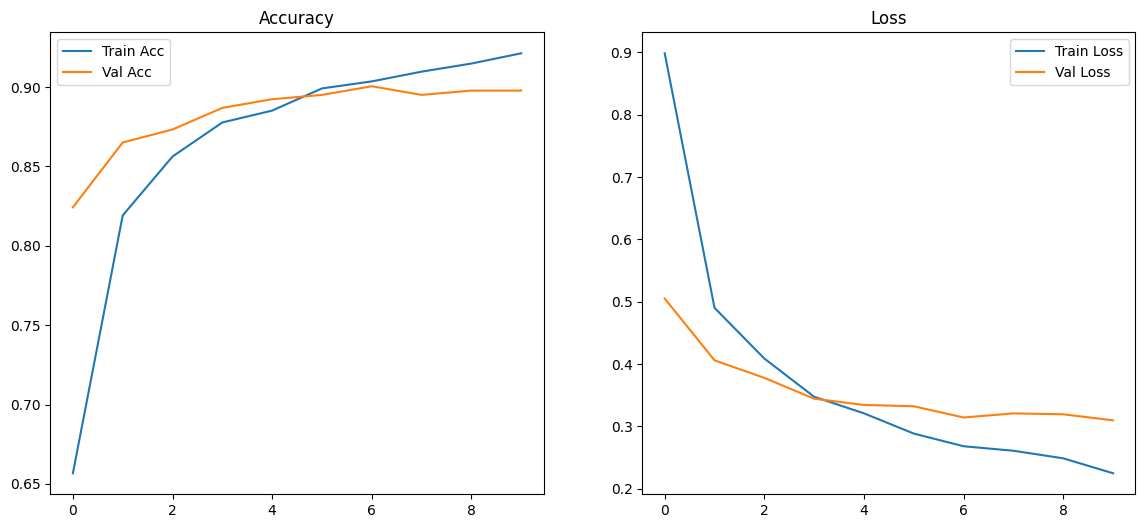

In [10]:
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9055 - loss: 0.3081
Test Accuracy: 0.8978201746940613


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


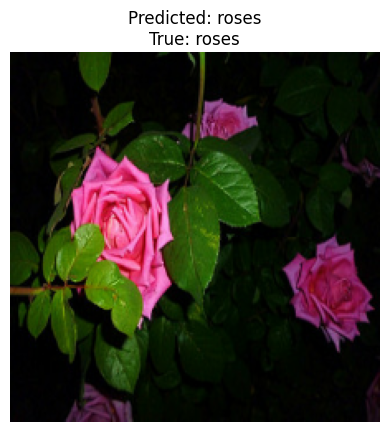

In [12]:
for images, labels in test_ds.take(1):
    sample_img = images[0]
    sample_label = labels[0]

    pred = model.predict(sample_img[None, ...])
    pred_class = np.argmax(pred)

    plt.imshow(sample_img)
    plt.title(f"Predicted: {class_names[pred_class]}\nTrue: {class_names[sample_label]}")
    plt.axis("off")
    plt.show()